KMeans Clusstering

In [26]:
from sklearn.datasets import load_iris
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist


In [2]:
iris = load_iris()

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [3]:
from IPython import display
from IPython.display import Markdown
display.Markdown(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Creator: R.A. Fisher
:Donor: Michael Marshall (MARSHALL%PLU@io.arc.nasa.gov)
:Date: July, 1988

The famous Iris database, first used by Sir R.A. Fisher. The dataset is taken
from Fisher's paper. Note that it's the same as in R, but not as in the UCI
Machine Learning Repository, which has two wrong data points.

This is perhaps the best known database to be found in the
pattern recognition literature.  Fisher's paper is a classic in the field and
is referenced frequently to this day.  (See Duda & Hart, for example.)  The
data set contains 3 classes of 50 instances each, where each class refers to a
type of iris plant.  One class is linearly separable from the other 2; the
latter are NOT linearly separable from each other.

|details-start|
**References**
|details-split|

- Fisher, R.A. "The use of multiple measurements in taxonomic problems"
  Annual Eugenics, 7, Part II, 179-188 (1936); also in "Contributions to
  Mathematical Statistics" (John Wiley, NY, 1950).
- Duda, R.O., & Hart, P.E. (1973) Pattern Classification and Scene Analysis.
  (Q327.D83) John Wiley & Sons.  ISBN 0-471-22361-1.  See page 218.
- Dasarathy, B.V. (1980) "Nosing Around the Neighborhood: A New System
  Structure and Classification Rule for Recognition in Partially Exposed
  Environments".  IEEE Transactions on Pattern Analysis and Machine
  Intelligence, Vol. PAMI-2, No. 1, 67-71.
- Gates, G.W. (1972) "The Reduced Nearest Neighbor Rule".  IEEE Transactions
  on Information Theory, May 1972, 431-433.
- See also: 1988 MLC Proceedings, 54-64.  Cheeseman et al"s AUTOCLASS II
  conceptual clustering system finds 3 classes in the data.
- Many, many more ...

|details-end|


In [14]:
iris1 = load_iris() 
iris1 = sns.load_dataset('iris') 
iris1.head() 

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


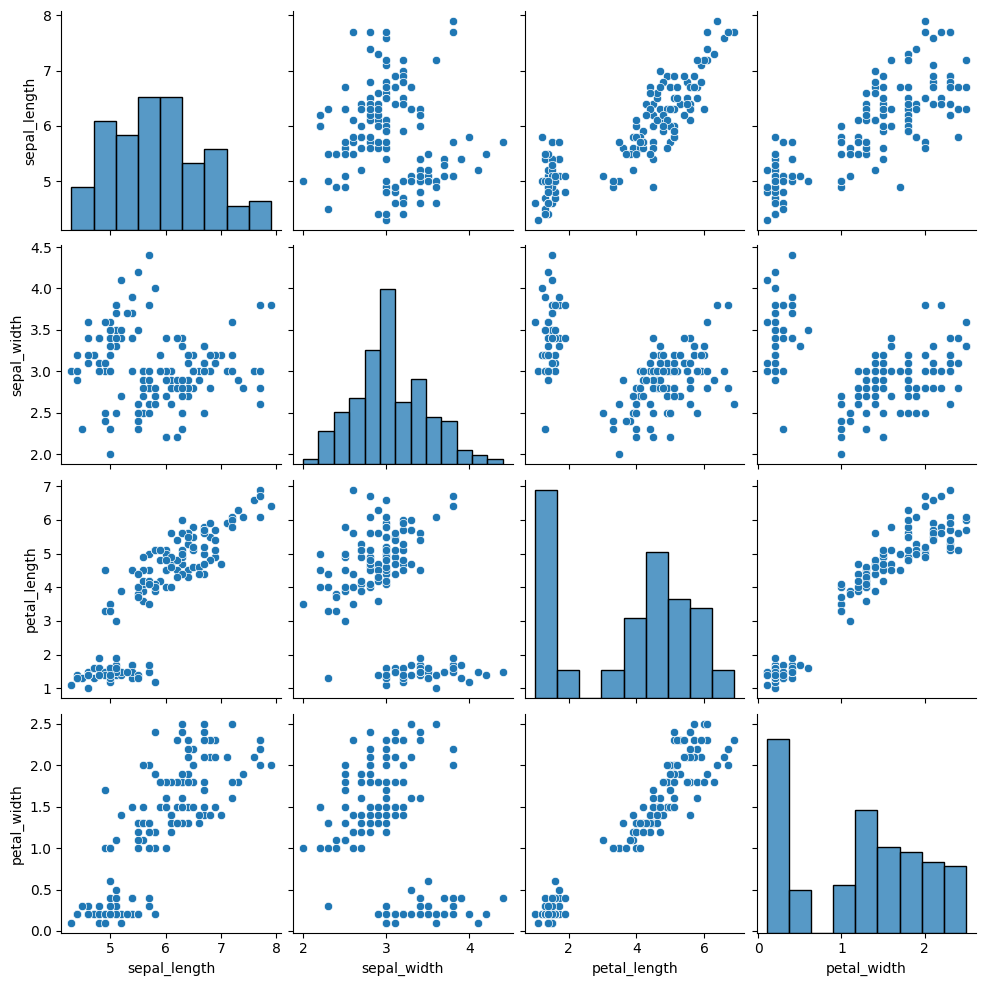

In [15]:
sns.pairplot(iris1)

In [9]:
df = pd.DataFrame(data = iris.data, columns = iris.feature_names)

In [10]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [51]:
X = iris1.iloc[:, :-2] #ambil semua kolom dari dari depan sampai kolom terakhir 2,
y = iris.target

In [32]:
#mencari jumlah k yang baik untuk model versi geeks for geeks
distortions = []
inertias = []
mapping1 = {}
mapping2 = {}
K = range(1,11)

for k in K:
    # Building and fitting the model
    kmeanModel = KMeans(n_clusters=k).fit(X)
    kmeanModel.fit(X)
 
    distortions.append(sum(np.min(cdist(X, kmeanModel.cluster_centers_,
                                        'euclidean'), axis=1)) / X.shape[0])
    inertias.append(kmeanModel.inertia_)
 
    mapping1[k] = sum(np.min(cdist(X, kmeanModel.cluster_centers_,
                                   'euclidean'), axis=1)) / X.shape[0]
    mapping2[k] = kmeanModel.inertia_



In [33]:
for key, val in mapping1.items():
    print(f'{key}:{val}')

1:1.9440683605553906
2:0.8555777695266533
3:0.6481657935591552
4:0.6103061360683173
5:0.5089665559584213
6:0.46638775718623643
7:0.447180651745488
8:0.4274918273923336
9:0.4033004299997875
10:0.390730671084063


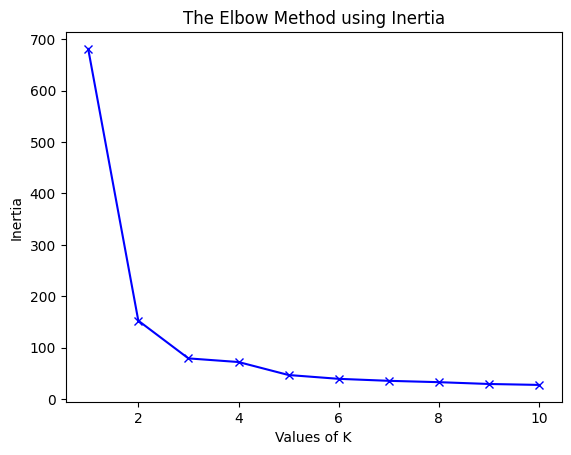

In [37]:
plt.plot(K, inertias, 'bx-')
plt.xlabel('Values of K')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.show()

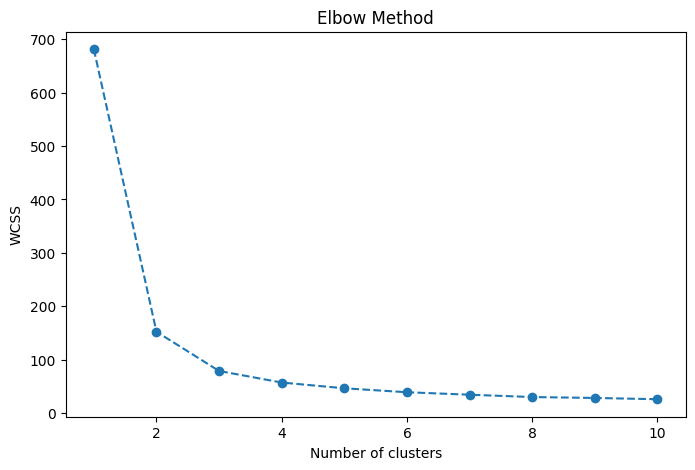

In [38]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)


# Plot the Elbow graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [49]:
#ini adalah versi chat gpt untuk menjadikan data menjadi datafram
# Create a DataFrame
"""df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add the target (species) to the DataFrame
df['species'] = iris.target

# Map the target numbers to actual species names
df['species'] = df['species'].map(dict(enumerate(iris.target_names)))

# Display the first few rows of the DataFrame
print(df.head())    """

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [42]:
# Visualising the clusters 
from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test = train_test_split(X, y, 
                                       test_size=0.33, 
                                       random_state=42) 


In [44]:
    
kmeans = KMeans(n_clusters=3, 
                init='k-means++', 
                max_iter=300, 
                n_init=10, 
                random_state=0) 
y_kmeans = kmeans.fit_predict(X) 

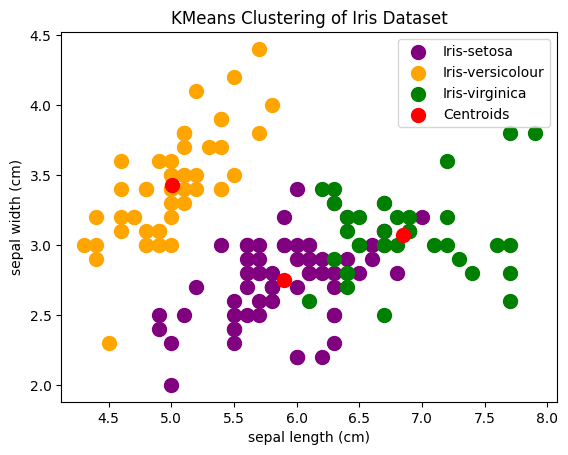

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets
from sklearn.cluster import KMeans

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Convert X to a DataFrame to use column names
df = pd.DataFrame(X, columns=iris.feature_names)

# Perform KMeans clustering
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=0)
y_kmeans = kmeans.fit_predict(X)

# Define the columns for plotting

plt.xlabel(cols[0])
plt.ylabel(cols[1])
plt.legend() 
plt.title('KMeans Clustering of Iris Dataset')
plt.show()



In [55]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


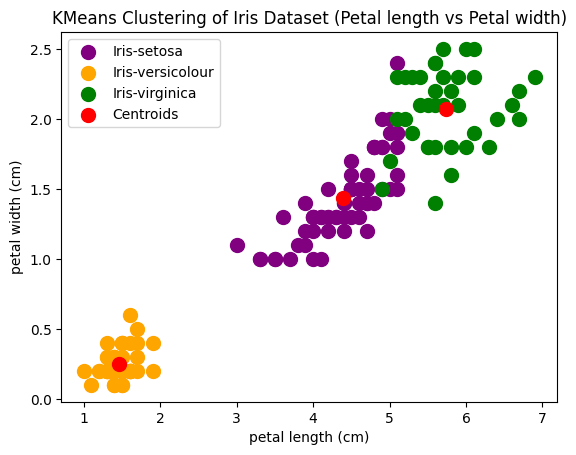

In [57]:
#efine the columns for plotting
cols = df.columns

# Plot the clusters using petal length and petal width
plt.scatter(df.iloc[y_kmeans == 0, 2], df.iloc[y_kmeans == 0, 3], 
            s=100, c='purple', label='Iris-setosa') 
plt.scatter(df.iloc[y_kmeans == 1, 2], df.iloc[y_kmeans == 1, 3], 
            s=100, c='orange', label='Iris-versicolour') 
plt.scatter(df.iloc[y_kmeans == 2, 2], df.iloc[y_kmeans == 2, 3], 
            s=100, c='green', label='Iris-virginica') 

# Plotting the centroids of the clusters 
plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3], 
            s=100, c='red', label='Centroids') 

plt.xlabel(cols[2])
plt.ylabel(cols[3])
plt.legend() 
plt.title('KMeans Clustering of Iris Dataset (Petal length vs Petal width)')
plt.show()